Section A

Install Libraries

In [ ]:
!pip install open_clip_torch timm transformers peft scikit-learn matplotlib seaborn grad-cam scikit-image opencv-python -q

Import Libraries

In [ ]:
import os
import cv2
import random
import pickle
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from skimage.measure import shannon_entropy

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import (
    datasets,
    transforms,
    models
)

from torch.utils.data import (
    DataLoader,
    Subset
)

Check GPU

In [ ]:
print("PyTorch Version:", torch.__version__)

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Create Complete Project Structure

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Indian_Food_Research"

folders = [

    "datasets",

    "datasets/IndianFood",

    "datasets/Food101",

    "figures",

    "figures/dataset",

    "figures/quality",

    "figures/training",

    "figures/evaluation",

    "models",

    "results",

    "reports",

    "splits"
]

for folder in folders:

    Path(
        f"{PROJECT_DIR}/{folder}"
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print("Project Structure Created")

Project Structure Created


Verify Folder Structure

In [ ]:
for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(
        PROJECT_DIR,
        ""
    ).count(os.sep)

    indent = " " * 4 * level

    print(
        f"{indent}{os.path.basename(root)}"
    )

Indian_Food_Research
    datasets
        IndianFood
        Food101
    figures
        dataset
        quality
        training
        evaluation
    models
    results
    reports
    splits


Create Plot Saving Utility

Every plot generated in the project will automatically save to Drive.

In [ ]:
def save_plot(
    name,
    folder="dataset"
):

    save_path = (
        f"{PROJECT_DIR}/figures/"
        f"{folder}/{name}.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        f"Saved -> {save_path}"
    )

Set Random Seeds

Important for reproducibility.

In [ ]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

print("Seed Fixed")

Seed Fixed


Dataset Path

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset"

print(
    os.path.exists(
        DATASET_PATH
    )
)

True


Create Transform

224×224 is required for ResNet, CLIP and DINOv2.

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.ToTensor()
])

Load Dataset

In [ ]:
dataset = datasets.ImageFolder(
    DATASET_PATH,
    transform=transform
)

print(
    "Images:",
    len(dataset)
)

print(
    "Classes:",
    len(dataset.classes)
)

Images: 4578
Classes: 100


Display First 20 Classes

In [ ]:
dataset.classes[:20]

['Aalubhat',
 'Alfredo_Pasta',
 'Aloo_Paratha',
 'Aloo_sabji',
 'Alu_vadi',
 'Appam',
 'Basundi',
 'Bhakri_thecha',
 'Bhindi_Sabji',
 'Bombay_Halwa',
 'Brinjal_Curry',
 'Brinjal_dry',
 'Cabbage_sabji',
 'Cauliflower_Sabji',
 'Chicken_bhuna_masala',
 'Chicken_biryani',
 'Chicken_crispy',
 'Chicken_curry',
 'Chicken_fry',
 'Chicken_soup']

Save Class Names

In [ ]:
class_df = pd.DataFrame(
    dataset.classes,
    columns=["Class"]
)

class_df.to_csv(
    f"{PROJECT_DIR}/reports/class_names.csv",
    index=False
)

print("Class Names Saved")

Class Names Saved


Dataset Sanity Check

In [ ]:
image, label = dataset[0]

print(
    image.shape
)

print(
    dataset.classes[label]
)

torch.Size([3, 224, 224])
Aalubhat


Visualize Random Samples

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/random_samples.png


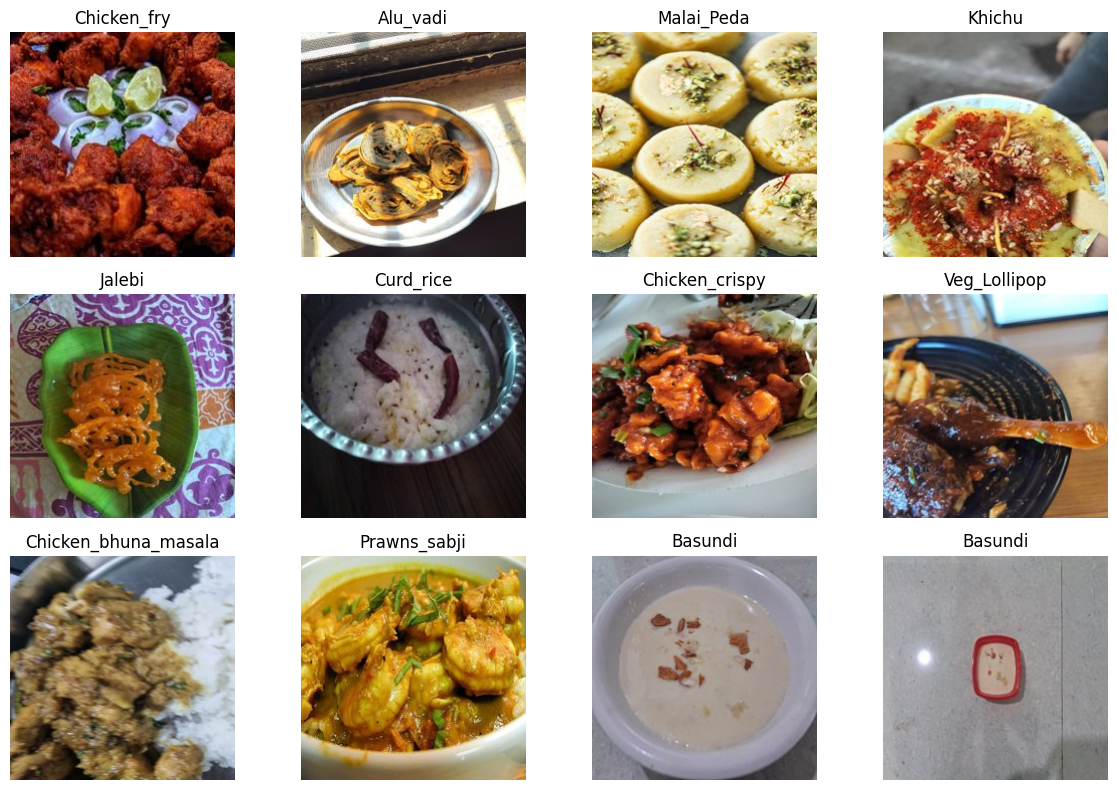

In [ ]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(12,8)
)

for ax in axes.flatten():

    idx = random.randint(
        0,
        len(dataset)-1
    )

    image, label = dataset[idx]

    image = image.permute(
        1,
        2,
        0
    )

    ax.imshow(image)

    ax.set_title(
        dataset.classes[label]
    )

    ax.axis("off")

plt.tight_layout()

save_plot(
    "random_samples",
    "dataset"
)

plt.show()

SECTION B — Dataset Statistics & Class Imbalance Analysis

Count Images Per Class

In [ ]:
class_counts = {}

for path, label in dataset.samples:

    class_name = dataset.classes[label]

    class_counts[class_name] = (
        class_counts.get(class_name, 0) + 1
    )

summary_df = pd.DataFrame(
    class_counts.items(),
    columns=["Dish", "Count"]
)

summary_df = summary_df.sort_values(
    by="Count",
    ascending=False
)

summary_df.head()

,Dish,Count
45,Kothimbir_Vadi,83
56,Methi_dry,82
53,Matar_Paneer,71
29,Dosa,70
47,Malai_Peda,69


Save Dataset Summary

In [ ]:
summary_df.to_csv(
    f"{PROJECT_DIR}/reports/dataset_summary.csv",
    index=False
)

print("Dataset Summary Saved")

Dataset Summary Saved


Basic Statistics

In [ ]:
stats = {

    "Total Classes":
        len(summary_df),

    "Total Images":
        summary_df["Count"].sum(),

    "Mean Images Per Class":
        round(summary_df["Count"].mean(), 2),

    "Median Images Per Class":
        round(summary_df["Count"].median(), 2),

    "Std Images Per Class":
        round(summary_df["Count"].std(), 2),

    "Max Images":
        summary_df["Count"].max(),

    "Min Images":
        summary_df["Count"].min(),

    "Imbalance Ratio":
        round(
            summary_df["Count"].max()
            /
            summary_df["Count"].min(),
            2
        )
}

stats_df = pd.DataFrame([stats])

stats_df

,Total Classes,Total Images,Mean Images Per Class,Median Images Per Class,Std Images Per Class,Max Images,Min Images,Imbalance Ratio
0,100,4578,45.78,50.0,17.1,83,7,11.86


Save Statistics

In [ ]:
stats_df.to_csv(
    f"{PROJECT_DIR}/reports/statistics.csv",
    index=False
)

print("Statistics Saved")

Statistics Saved


Class Distribution Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/class_distribution.png


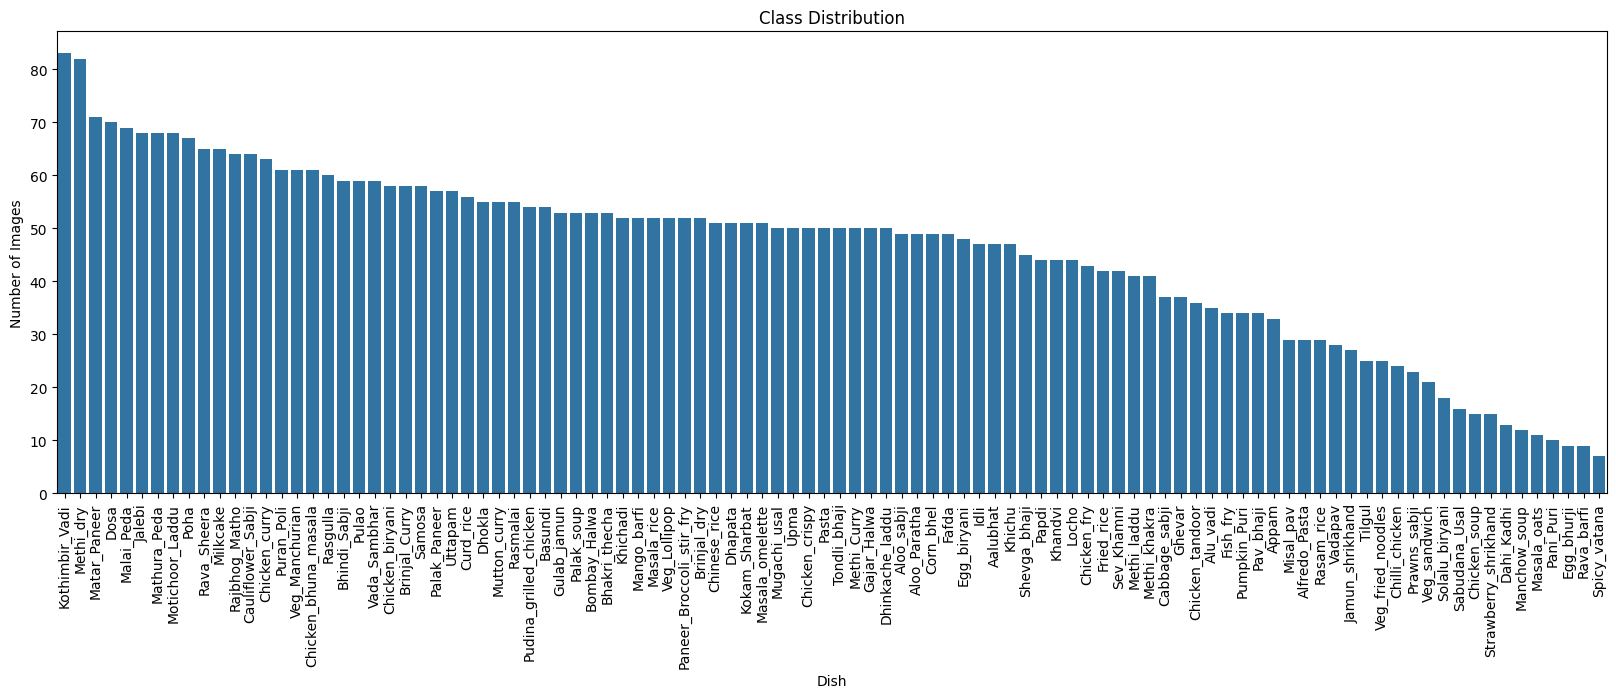

In [ ]:
plt.figure(figsize=(20,6))

sns.barplot(
    x=summary_df["Dish"],
    y=summary_df["Count"]
)

plt.xticks(rotation=90)

plt.title(
    "Class Distribution"
)

plt.xlabel("Dish")

plt.ylabel("Number of Images")

save_plot(
    "class_distribution",
    "dataset"
)

plt.show()

Top 20 Largest Classes

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/largest_classes.png


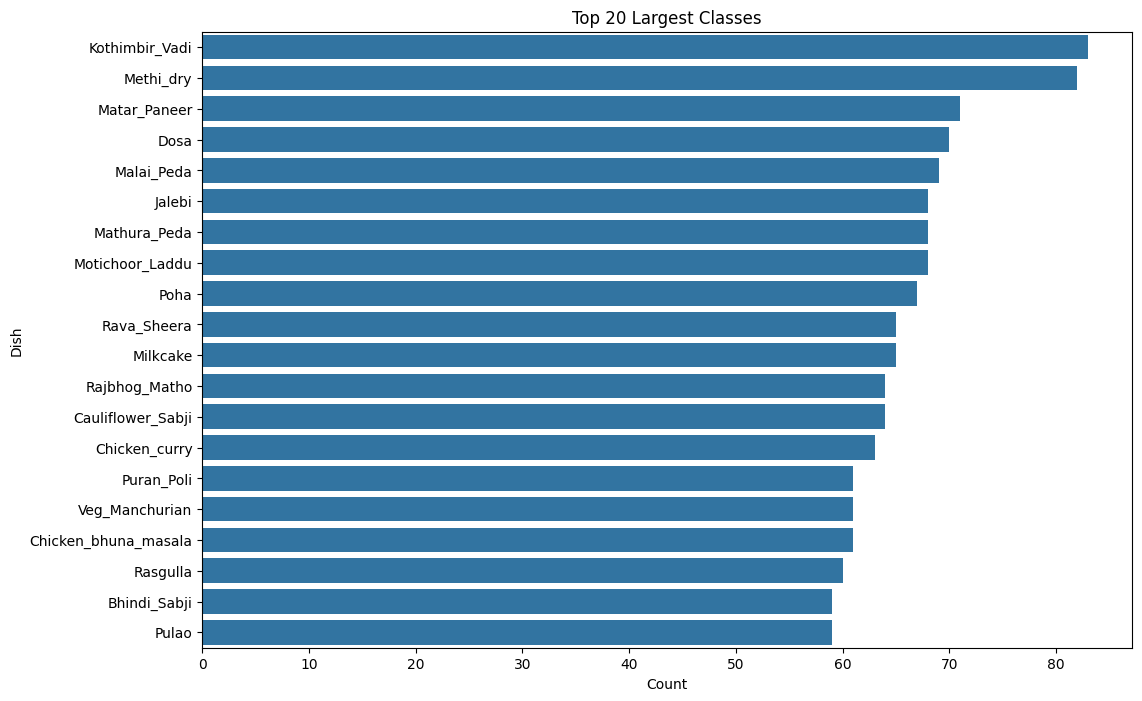

In [ ]:
largest = summary_df.nlargest(
    20,
    "Count"
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=largest,
    x="Count",
    y="Dish"
)

plt.title(
    "Top 20 Largest Classes"
)

save_plot(
    "largest_classes",
    "dataset"
)

plt.show()

Top 20 Smallest Classes

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/smallest_classes.png


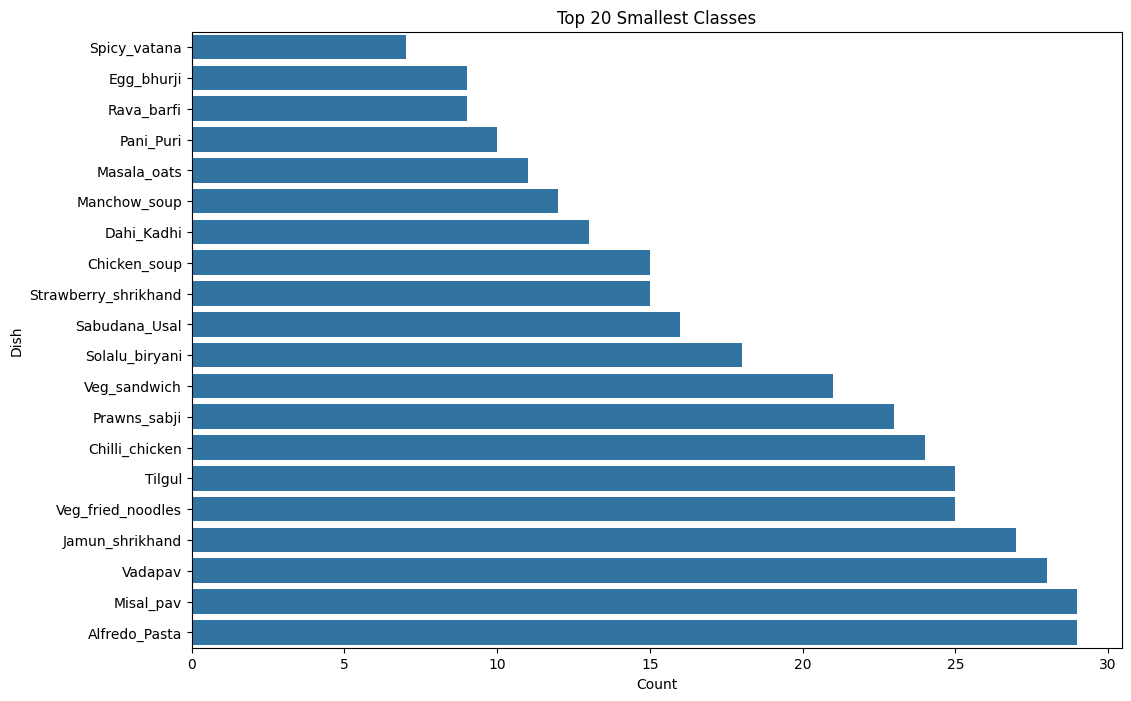

In [ ]:
smallest = summary_df.nsmallest(
    20,
    "Count"
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=smallest,
    x="Count",
    y="Dish"
)

plt.title(
    "Top 20 Smallest Classes"
)

save_plot(
    "smallest_classes",
    "dataset"
)

plt.show()

Histogram of Class Counts

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/class_count_histogram.png


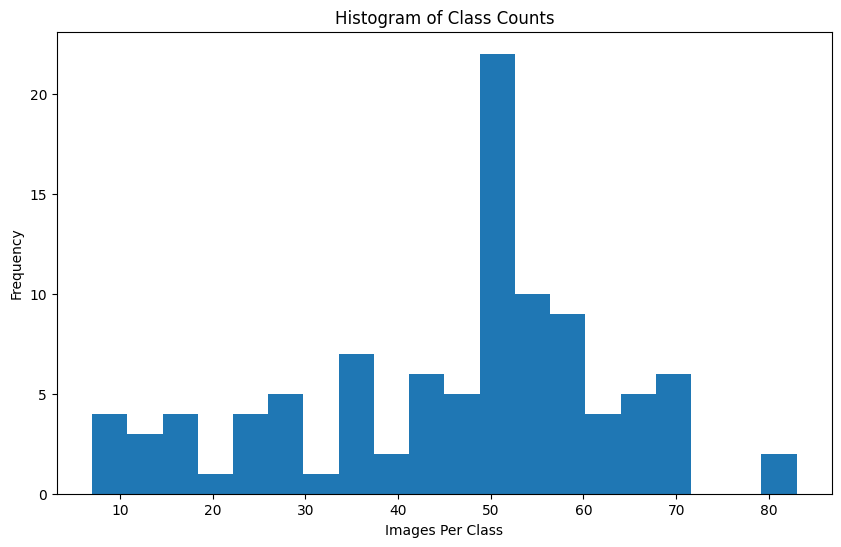

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    summary_df["Count"],
    bins=20
)

plt.title(
    "Histogram of Class Counts"
)

plt.xlabel(
    "Images Per Class"
)

plt.ylabel(
    "Frequency"
)

save_plot(
    "class_count_histogram",
    "dataset"
)

plt.show()

Boxplot for Class Counts

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/class_count_boxplot.png


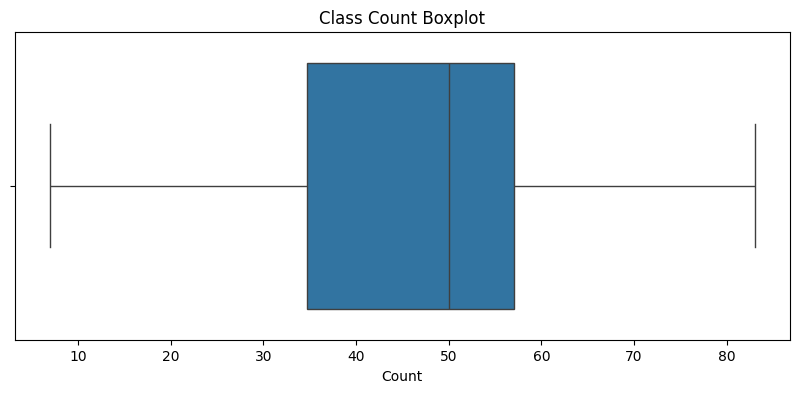

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=summary_df["Count"]
)

plt.title(
    "Class Count Boxplot"
)

save_plot(
    "class_count_boxplot",
    "dataset"
)

plt.show()

Pie Chart (Largest 10 Classes)

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/top10_distribution.png


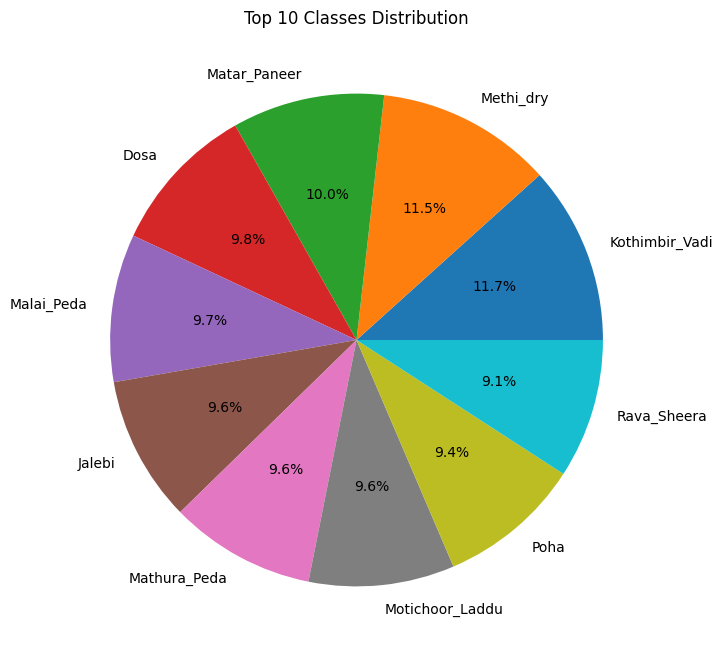

In [ ]:
top10 = summary_df.nlargest(
    10,
    "Count"
)

plt.figure(figsize=(8,8))

plt.pie(
    top10["Count"],
    labels=top10["Dish"],
    autopct="%1.1f%%"
)

plt.title(
    "Top 10 Classes Distribution"
)

save_plot(
    "top10_distribution",
    "dataset"
)

plt.show()

Detect Rare Classes

In [ ]:
threshold = (
    summary_df["Count"].mean()
    * 0.5
)

rare_classes = summary_df[
    summary_df["Count"] < threshold
]

print(
    "Rare Classes:",
    len(rare_classes)
)

rare_classes.head()

Rare Classes: 12


,Dish,Count
99,Veg_sandwich,21
87,Solalu_biryani,18
83,Sabudana_Usal,16
19,Chicken_soup,15
89,Strawberry_shrikhand,15


Save Rare Classes

In [ ]:
rare_classes.to_csv(
    f"{PROJECT_DIR}/reports/rare_classes.csv",
    index=False
)

print("Rare Classes Saved")

Rare Classes Saved


Dataset Summary Report

In [ ]:
print("="*50)

print("DATASET SUMMARY")

print("="*50)

for key, value in stats.items():
    print(f"{key}: {value}")

print("="*50)

DATASET SUMMARY
Total Classes: 100
Total Images: 4578
Mean Images Per Class: 45.78
Median Images Per Class: 50.0
Std Images Per Class: 17.1
Max Images: 83
Min Images: 7
Imbalance Ratio: 11.86


Generate Publication Table

This table can directly go into the paper.

In [ ]:
paper_table = pd.DataFrame({

    "Metric":[
        "Total Images",
        "Total Classes",
        "Mean Images/Class",
        "Median Images/Class",
        "Maximum Images/Class",
        "Minimum Images/Class",
        "Imbalance Ratio"
    ],

    "Value":[
        stats["Total Images"],
        stats["Total Classes"],
        stats["Mean Images Per Class"],
        stats["Median Images Per Class"],
        stats["Max Images"],
        stats["Min Images"],
        stats["Imbalance Ratio"]
    ]
})

paper_table

,Metric,Value
0,Total Images,4578.00
1,Total Classes,100.00
2,Mean Images/Class,45.78
3,Median Images/Class,50.00
4,Maximum Images/Class,83.00
5,Minimum Images/Class,7.00
6,Imbalance Ratio,11.86


Save Publication Table

In [ ]:
paper_table.to_csv(
    f"{PROJECT_DIR}/reports/paper_dataset_table.csv",
    index=False
)

print(
    "Paper Dataset Table Saved"
)

Paper Dataset Table Saved


SECTION C — Dataset Quality Analysis

Resolution Analysis

In [ ]:
widths = []
heights = []

for path, _ in dataset.samples:

    img = Image.open(path)

    widths.append(
        img.size[0]
    )

    heights.append(
        img.size[1]
    )

print(
    "Average Width:",
    np.mean(widths)
)

print(
    "Average Height:",
    np.mean(heights)
)

Average Width: 224.0
Average Height: 224.0


Resolution Statistics

In [ ]:
resolution_df = pd.DataFrame({

    "Width": widths,
    "Height": heights

})

resolution_df.describe()

,Width,Height
count,4578.0,4578.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


Save Resolution Statistics

In [ ]:
resolution_df.to_csv(
    f"{PROJECT_DIR}/results/resolution_statistics.csv",
    index=False
)

print(
    "Resolution Statistics Saved"
)

Resolution Statistics Saved


Resolution Scatter Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/resolution_distribution.png


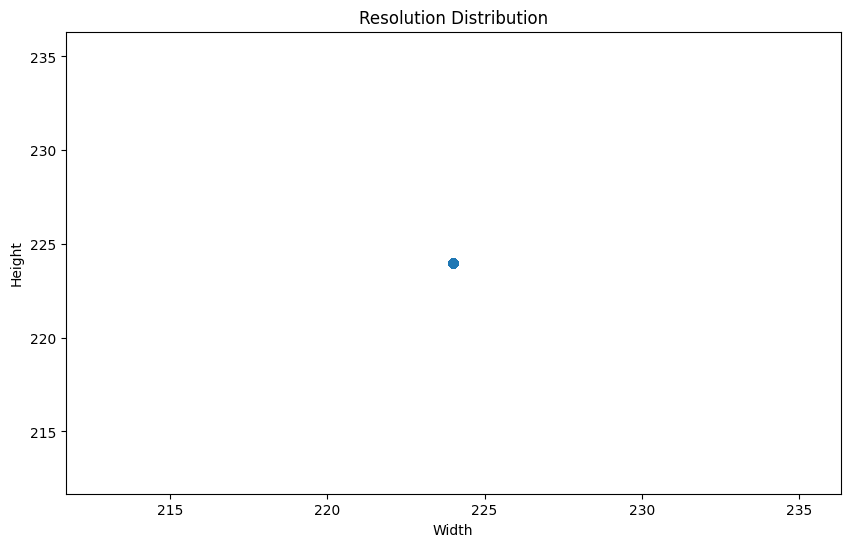

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    widths,
    heights,
    alpha=0.4
)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title(
    "Resolution Distribution"
)

save_plot(
    "resolution_distribution",
    "quality"
)

plt.show()

Resolution Histogram

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/resolution_histogram.png


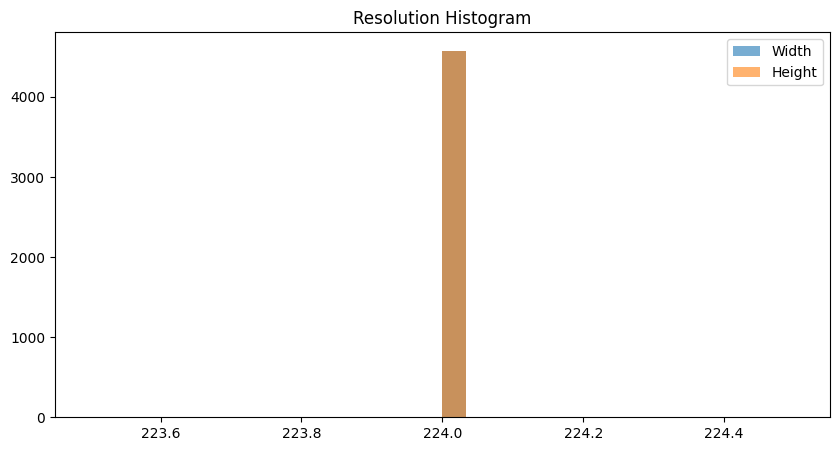

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    widths,
    bins=30,
    alpha=0.6,
    label="Width"
)

plt.hist(
    heights,
    bins=30,
    alpha=0.6,
    label="Height"
)

plt.legend()

plt.title(
    "Resolution Histogram"
)

save_plot(
    "resolution_histogram",
    "quality"
)

plt.show()

Brightness Analysis

In [ ]:
brightness_scores = []

for path, _ in dataset.samples:

    img = Image.open(path)

    img = img.convert("L")

    brightness_scores.append(
        np.array(img).mean()
    )

Brightness Statistics

In [ ]:
brightness_df = pd.DataFrame({

    "Brightness":
        brightness_scores
})

brightness_df.describe()

,Brightness
count,4578.000000
mean,111.878479
std,29.894308
min,16.347736
25%,90.514474
50%,111.136589
75%,130.118986
max,251.813098


Save Brightness Statistics

In [ ]:
brightness_df.to_csv(
    f"{PROJECT_DIR}/results/brightness_statistics.csv",
    index=False
)

Brightness Distribution Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/brightness_distribution.png


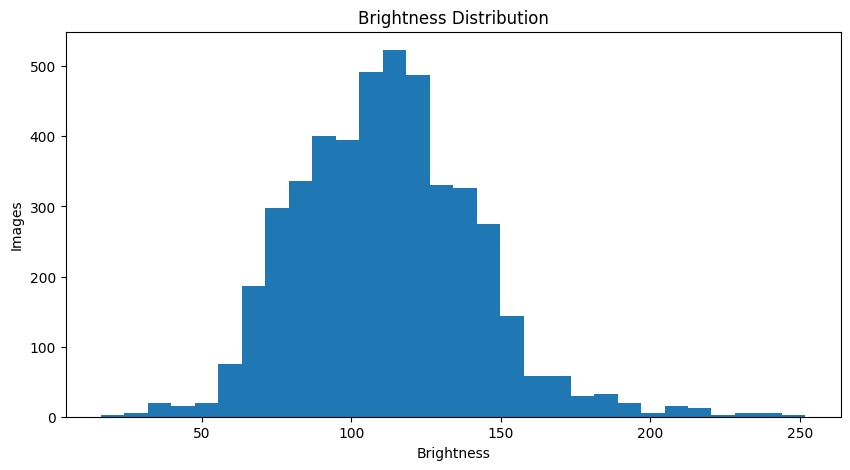

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    brightness_scores,
    bins=30
)

plt.title(
    "Brightness Distribution"
)

plt.xlabel(
    "Brightness"
)

plt.ylabel(
    "Images"
)

save_plot(
    "brightness_distribution",
    "quality"
)

plt.show()

Contrast Analysis

In [ ]:
contrast_scores = []

for path, _ in dataset.samples:

    img = Image.open(path)

    img = img.convert("L")

    contrast_scores.append(
        np.array(img).std()
    )

Contrast Statistics

In [ ]:
contrast_df = pd.DataFrame({

    "Contrast":
        contrast_scores
})

contrast_df.describe()

,Contrast
count,4578.000000
mean,49.577218
std,10.823233
min,10.231934
25%,43.146937
50%,49.602280
75%,55.991138
max,101.260312


Save Contrast Statistics

In [ ]:
contrast_df.to_csv(
    f"{PROJECT_DIR}/results/contrast_statistics.csv",
    index=False
)

Contrast Distribution Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/contrast_distribution.png


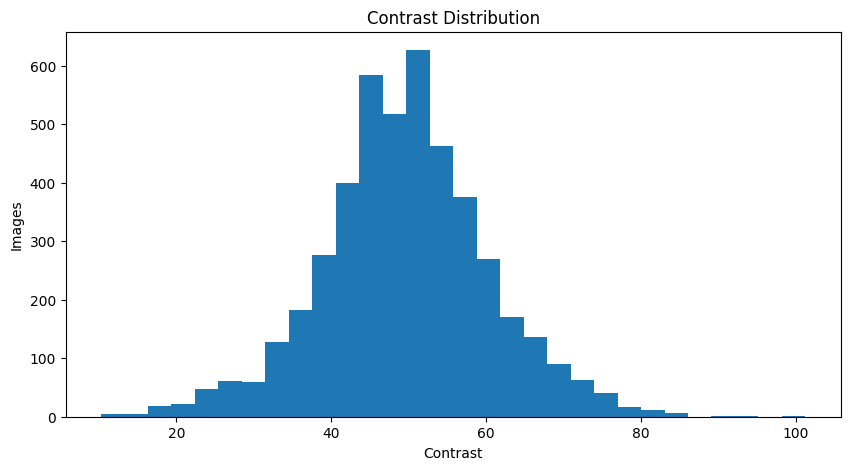

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    contrast_scores,
    bins=30
)

plt.title(
    "Contrast Distribution"
)

plt.xlabel(
    "Contrast"
)

plt.ylabel(
    "Images"
)

save_plot(
    "contrast_distribution",
    "quality"
)

plt.show()

Blur Detection

Variance of Laplacian is commonly used.

In [ ]:
blur_scores = []

for path, _ in dataset.samples:

    img = cv2.imread(path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    blur_scores.append(score)

Blur Statistics

In [ ]:
blur_df = pd.DataFrame({

    "BlurScore":
        blur_scores
})

blur_df.describe()

,BlurScore
count,4578.000000
mean,940.252275
std,752.276013
min,5.163003
25%,477.992073
50%,769.642957
75%,1188.577317
max,8645.134357


Save Blur Statistics

In [ ]:
blur_df.to_csv(
    f"{PROJECT_DIR}/results/blur_statistics.csv",
    index=False
)

Blur Distribution Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/blur_distribution.png


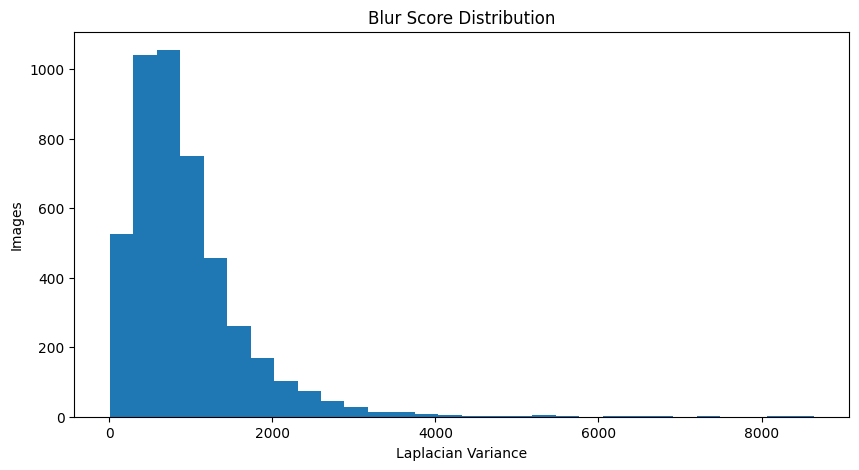

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    blur_scores,
    bins=30
)

plt.title(
    "Blur Score Distribution"
)

plt.xlabel(
    "Laplacian Variance"
)

plt.ylabel(
    "Images"
)

save_plot(
    "blur_distribution",
    "quality"
)

plt.show()

Entropy Analysis

In [ ]:
entropy_scores = []

for path, _ in dataset.samples:

    img = Image.open(path)

    entropy_scores.append(
        shannon_entropy(img)
    )

Entropy Statistics

In [ ]:
entropy_df = pd.DataFrame({

    "Entropy":
        entropy_scores
})

entropy_df.describe()

,Entropy
count,4578.000000
mean,7.443869
std,0.431996
min,2.059831
25%,7.325243
50%,7.545254
75%,7.701097
max,7.971475


Save Entropy Statistics

In [ ]:
entropy_df.to_csv(
    f"{PROJECT_DIR}/results/entropy_statistics.csv",
    index=False
)

Entropy Distribution Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/entropy_distribution.png


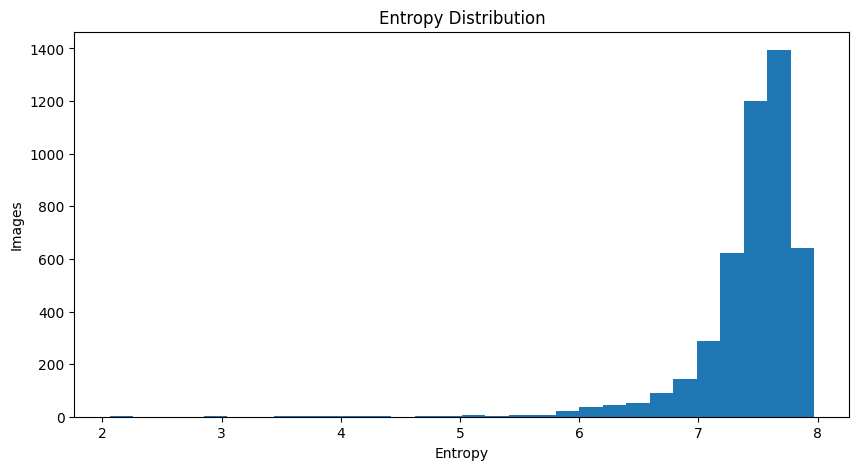

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    entropy_scores,
    bins=30
)

plt.title(
    "Entropy Distribution"
)

plt.xlabel(
    "Entropy"
)

plt.ylabel(
    "Images"
)

save_plot(
    "entropy_distribution",
    "quality"
)

plt.show()

Combined Quality Metrics DataFrame

In [ ]:
quality_df = pd.DataFrame({

    "Brightness":
        brightness_scores,

    "Contrast":
        contrast_scores,

    "Blur":
        blur_scores,

    "Entropy":
        entropy_scores

})

quality_df.head()

,Brightness,Contrast,Blur,Entropy
0,129.377770,38.660230,2634.289336,7.514742
1,120.272341,54.686480,1626.383526,7.703103
2,128.119659,39.863808,2163.695621,7.600139
3,100.477021,42.704178,1268.370268,7.518696
4,221.730947,29.213078,543.701068,6.544180


Save Quality Metrics

In [ ]:
quality_df.to_csv(
    f"{PROJECT_DIR}/results/quality_metrics.csv",
    index=False
)

print(
    "Quality Metrics Saved"
)

Quality Metrics Saved


Correlation Matrix

In [ ]:
corr = quality_df.corr()

corr

,Brightness,Contrast,Blur,Entropy
Brightness,1.000000,-0.006049,0.072865,-0.087187
Contrast,-0.006049,1.000000,0.237027,0.455053
Blur,0.072865,0.237027,1.000000,0.267682
Entropy,-0.087187,0.455053,0.267682,1.000000


Correlation Heatmap

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/quality_correlation.png


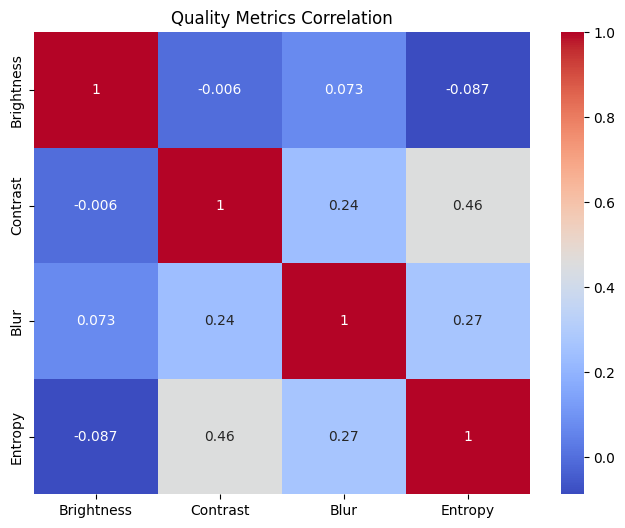

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Quality Metrics Correlation"
)

save_plot(
    "quality_correlation",
    "quality"
)

plt.show()

Combined Quality Boxplots

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/quality/quality_boxplots.png


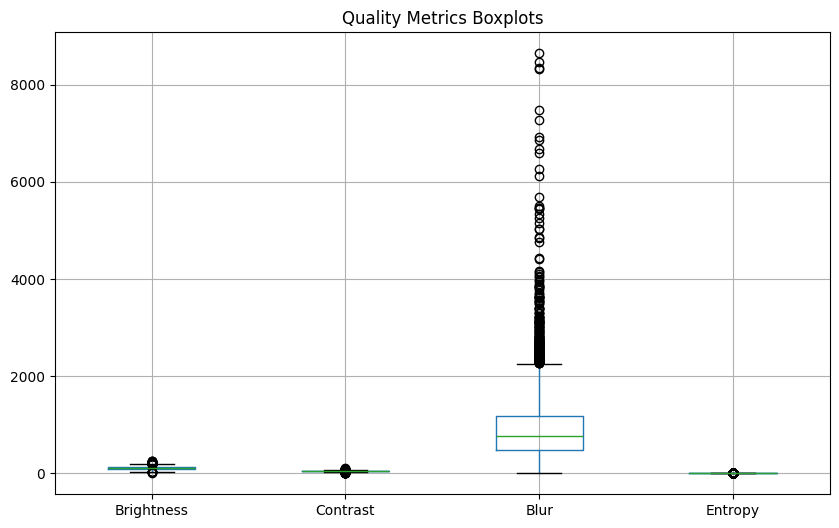

In [ ]:
plt.figure(figsize=(10,6))

quality_df.boxplot()

plt.title(
    "Quality Metrics Boxplots"
)

save_plot(
    "quality_boxplots",
    "quality"
)

plt.show()

Quality Report

In [ ]:
quality_report = quality_df.describe()

quality_report

,Brightness,Contrast,Blur,Entropy
count,4578.000000,4578.000000,4578.000000,4578.000000
mean,111.878479,49.577218,940.252275,7.443869
std,29.894308,10.823233,752.276013,0.431996
min,16.347736,10.231934,5.163003,2.059831
25%,90.514474,43.146937,477.992073,7.325243
50%,111.136589,49.602280,769.642957,7.545254
75%,130.118986,55.991138,1188.577317,7.701097
max,251.813098,101.260312,8645.134357,7.971475


Save Quality Report

In [ ]:
quality_report.to_csv(
    f"{PROJECT_DIR}/reports/quality_report.csv"
)

print(
    "Quality Report Saved"
)

Quality Report Saved


SECTION D — Train / Validation / Test Split (70 / 15 / 15)

Create Stratified Split

In [ ]:
indices = list(
    range(len(dataset))
)

targets = dataset.targets

train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    stratify=targets,

    random_state=42
)

temp_targets = [
    targets[i]
    for i in temp_idx
]

val_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    stratify=temp_targets,

    random_state=42
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 3204
Validation: 687
Test: 687


Verify Split Ratios

In [ ]:
total = len(dataset)

print(
    f"Train %: {100*len(train_idx)/total:.2f}"
)

print(
    f"Validation %: {100*len(val_idx)/total:.2f}"
)

print(
    f"Test %: {100*len(test_idx)/total:.2f}"
)

Train %: 69.99
Validation %: 15.01
Test %: 15.01


Save Splits

In [ ]:
with open(
    f"{PROJECT_DIR}/splits/train_idx.pkl",
    "wb"
) as f:

    pickle.dump(
        train_idx,
        f
    )

with open(
    f"{PROJECT_DIR}/splits/val_idx.pkl",
    "wb"
) as f:

    pickle.dump(
        val_idx,
        f
    )

with open(
    f"{PROJECT_DIR}/splits/test_idx.pkl",
    "wb"
) as f:

    pickle.dump(
        test_idx,
        f
    )

print("Splits Saved")

Splits Saved


Verify Saved Splits

In [ ]:
with open(
    f"{PROJECT_DIR}/splits/train_idx.pkl",
    "rb"
) as f:

    loaded_train = pickle.load(f)

print(
    "Loaded Train Samples:",
    len(loaded_train)
)

Loaded Train Samples: 3204


Create Dataset Objects

In [ ]:
train_set = Subset(
    dataset,
    train_idx
)

val_set = Subset(
    dataset,
    val_idx
)

test_set = Subset(
    dataset,
    test_idx
)

Dataset Sizes

In [ ]:
print(
    "Train Set:",
    len(train_set)
)

print(
    "Validation Set:",
    len(val_set)
)

print(
    "Test Set:",
    len(test_set)
)

Train Set: 3204
Validation Set: 687
Test Set: 687


Create DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(

    train_set,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2
)

val_loader = DataLoader(

    val_set,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2
)

test_loader = DataLoader(

    test_set,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2
)

Verify DataLoader

In [ ]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Split Pie Chart

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/dataset_split.png


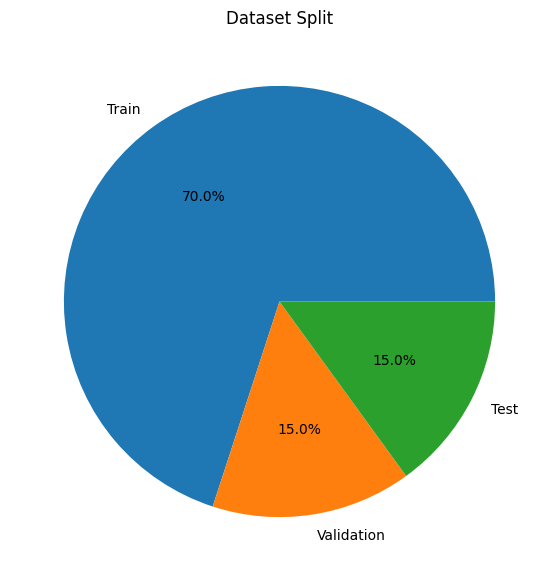

In [ ]:
sizes = [

    len(train_idx),

    len(val_idx),

    len(test_idx)
]

labels = [

    "Train",

    "Validation",

    "Test"
]

plt.figure(
    figsize=(7,7)
)

plt.pie(

    sizes,

    labels=labels,

    autopct="%1.1f%%"
)

plt.title(
    "Dataset Split"
)

save_plot(
    "dataset_split",
    "dataset"
)

plt.show()

Per-Class Counts

In [ ]:
class_names = dataset.classes

train_counts = {
    c:0 for c in class_names
}

val_counts = {
    c:0 for c in class_names
}

test_counts = {
    c:0 for c in class_names
}

Count Train Samples Per Class

In [ ]:
for idx in train_idx:

    label = dataset.targets[idx]

    class_name = class_names[label]

    train_counts[class_name] += 1

Count Validation Samples

In [ ]:
for idx in val_idx:

    label = dataset.targets[idx]

    class_name = class_names[label]

    val_counts[class_name] += 1

Count Test Samples

In [ ]:
for idx in test_idx:

    label = dataset.targets[idx]

    class_name = class_names[label]

    test_counts[class_name] += 1

Create Split Summary Table

In [ ]:
split_df = pd.DataFrame({

    "Class":
        class_names,

    "Train":
        [
            train_counts[c]
            for c in class_names
        ],

    "Validation":
        [
            val_counts[c]
            for c in class_names
        ],

    "Test":
        [
            test_counts[c]
            for c in class_names
        ]
})

split_df.head()

,Class,Train,Validation,Test
0,Aalubhat,33,7,7
1,Alfredo_Pasta,20,4,5
2,Aloo_Paratha,34,7,8
3,Aloo_sabji,34,7,8
4,Alu_vadi,24,6,5


Save Split Table

In [ ]:
split_df.to_csv(

    f"{PROJECT_DIR}/reports/split_summary.csv",

    index=False
)

print(
    "Split Summary Saved"
)

Split Summary Saved


Visualize Class Distribution Across Splits

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/dataset/split_verification.png


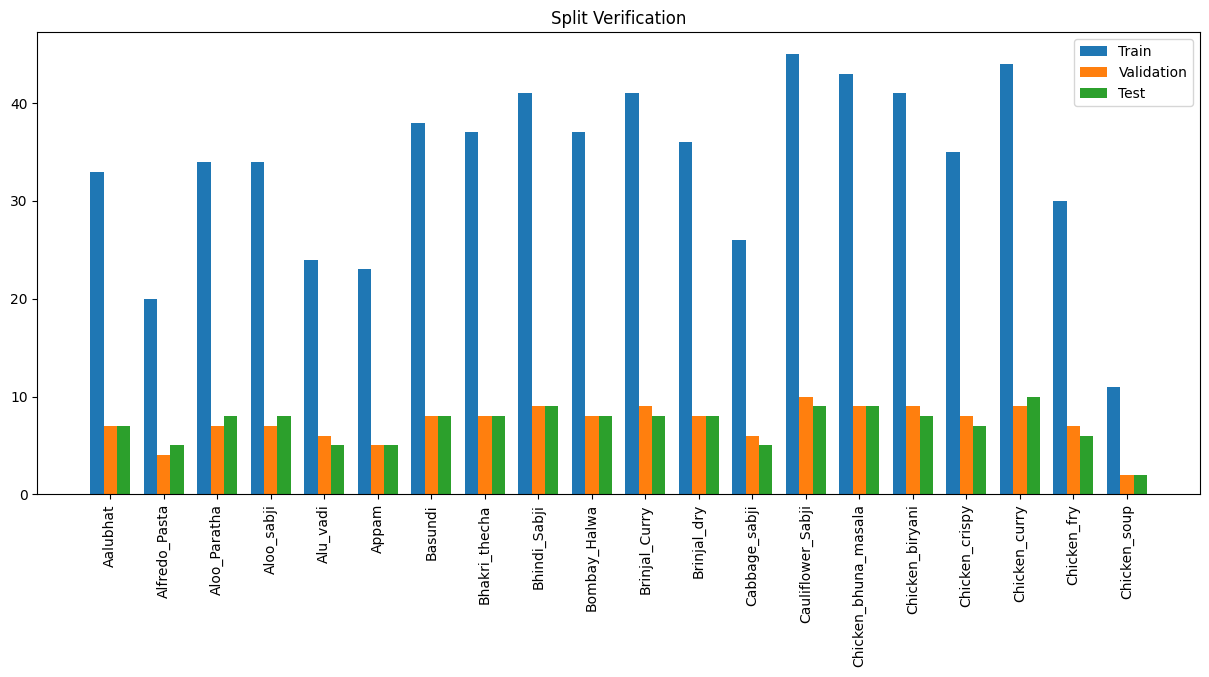

In [ ]:
sample_classes = split_df.head(20)

plt.figure(
    figsize=(15,6)
)

x = np.arange(
    len(sample_classes)
)

width = 0.25

plt.bar(

    x-width,

    sample_classes["Train"],

    width,

    label="Train"
)

plt.bar(

    x,

    sample_classes["Validation"],

    width,

    label="Validation"
)

plt.bar(

    x+width,

    sample_classes["Test"],

    width,

    label="Test"
)

plt.xticks(

    x,

    sample_classes["Class"],

    rotation=90
)

plt.legend()

plt.title(
    "Split Verification"
)

save_plot(
    "split_verification",
    "dataset"
)

plt.show()

Check Stratification Quality

In [ ]:
split_df["Train_Ratio"] = (

    split_df["Train"]

    /

    (
        split_df["Train"]

        +

        split_df["Validation"]

        +

        split_df["Test"]
    )
)

split_df["Validation_Ratio"] = (

    split_df["Validation"]

    /

    (
        split_df["Train"]

        +

        split_df["Validation"]

        +

        split_df["Test"]
    )
)

split_df["Test_Ratio"] = (

    split_df["Test"]

    /

    (
        split_df["Train"]

        +

        split_df["Validation"]

        +

        split_df["Test"]
    )
)

split_df.head()

,Class,Train,Validation,Test,Train_Ratio,Validation_Ratio,Test_Ratio
0,Aalubhat,33,7,7,0.702128,0.148936,0.148936
1,Alfredo_Pasta,20,4,5,0.689655,0.137931,0.172414
2,Aloo_Paratha,34,7,8,0.693878,0.142857,0.163265
3,Aloo_sabji,34,7,8,0.693878,0.142857,0.163265
4,Alu_vadi,24,6,5,0.685714,0.171429,0.142857


Save Stratification Report

In [ ]:
split_df.to_csv(

    f"{PROJECT_DIR}/reports/stratification_report.csv",

    index=False
)

print(
    "Stratification Report Saved"
)

Stratification Report Saved


SECTION E — ResNet50 From-Scratch Baseline Training

This is the baseline required by your project brief. Later, CLIP, DINOv2, and LoRA must be compared against this baseline.

Device Configuration

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


Data Augmentation for Training

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((256,256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8,1.0)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.RandomPerspective(
        distortion_scale=0.2,
        p=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]
    )
])

Reload Dataset with Augmentation

In [ ]:
train_dataset = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

eval_dataset = datasets.ImageFolder(
    DATASET_PATH,
    transform=test_transform
)

Recreate Split Datasets

In [ ]:
train_set = Subset(
    train_dataset,
    train_idx
)

val_set = Subset(
    eval_dataset,
    val_idx
)

test_set = Subset(
    eval_dataset,
    test_idx
)

Recreate DataLoaders

In [ ]:
train_loader = DataLoader(

    train_set,

    batch_size=32,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_set,

    batch_size=32,

    shuffle=False,

    num_workers=2
)

test_loader = DataLoader(

    test_set,

    batch_size=32,

    shuffle=False,

    num_workers=2
)

Create ResNet50

In [ ]:
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

num_classes = len(dataset.classes)

model = resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V2
)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model)

print(
    "\nNumber of Classes:",
    num_classes
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 47.0MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Count Parameters

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 23,712,932
Trainable Parameters: 23,712,932


Loss Function

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(dataset.targets),

    y=dataset.targets
)

weights = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

Optimizer

In [ ]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=3e-4,

    weight_decay=1e-4
)

Learning Rate Scheduler

In [ ]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

Mixed Precision

In [ ]:
scaler = torch.cuda.amp.GradScaler()

Early Stopping Variables

In [ ]:
best_val_acc = 0

patience = 7

counter = 0

Training Configuration

In [ ]:
EPOCHS = 35

train_losses = []

val_losses = []

train_accs = []

val_accs = []

Training Function

In [ ]:
def train_epoch():

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    acc = correct / total

    loss = (
        running_loss /
        len(train_loader)
    )

    return loss, acc

Validation Function

In [ ]:
def validate():

    model.eval()

    running_loss = 0

    correct = 0

    top5_correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            _, top5 = outputs.topk(
                5,
                dim=1
            )

            top5_correct += (
                top5 ==
                labels.view(-1,1)
            ).sum().item()

            total += labels.size(0)

    loss = running_loss / len(val_loader)

    acc = correct / total

    top5_acc = top5_correct / total

    return loss, acc, top5_acc

Main Training Loop

In [ ]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch()

    val_loss, val_acc, val_top5 = validate()

    scheduler.step(val_loss)

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    train_accs.append(
        train_acc
    )

    val_accs.append(
        val_acc
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            f"{PROJECT_DIR}/models/best_resnet50.pth"
        )

        print(
            f"Best Model Saved (Val Acc={val_acc:.4f})"
        )

    else:

        counter += 1

    if counter >= patience:

        print(
            "Early Stopping"
        )

        break
    print(
        f"Val Top5: {val_top5:.4f}"
    )

Epoch 1/35
Train Loss: 0.7829
Val Loss: 0.6962
Train Acc: 0.8190
Val Acc: 0.8370
Best Model Saved (Val Acc=0.8370)
Val Top5: 0.9578
Epoch 2/35
Train Loss: 0.4041
Val Loss: 0.5236
Train Acc: 0.8908
Val Acc: 0.8821
Best Model Saved (Val Acc=0.8821)
Val Top5: 0.9563
Epoch 3/35
Train Loss: 0.2830
Val Loss: 0.6503
Train Acc: 0.9245
Val Acc: 0.8384
Val Top5: 0.9505
Epoch 4/35
Train Loss: 0.1979
Val Loss: 0.6366
Train Acc: 0.9513
Val Acc: 0.8748
Val Top5: 0.9592
Epoch 5/35
Train Loss: 0.1422
Val Loss: 0.5413
Train Acc: 0.9576
Val Acc: 0.8617
Val Top5: 0.9622
Epoch 6/35
Train Loss: 0.1278
Val Loss: 0.6285
Train Acc: 0.9654
Val Acc: 0.8777
Val Top5: 0.9651
Epoch 7/35
Train Loss: 0.1602
Val Loss: 0.5665
Train Acc: 0.9591
Val Acc: 0.8675
Val Top5: 0.9578
Epoch 8/35
Train Loss: 0.1019
Val Loss: 0.5948
Train Acc: 0.9732
Val Acc: 0.8937
Best Model Saved (Val Acc=0.8937)
Val Top5: 0.9534
Epoch 9/35
Train Loss: 0.1173
Val Loss: 0.6491
Train Acc: 0.9722
Val Acc: 0.8719
Val Top5: 0.9622
Epoch 10/35
Trai

Save Training History

In [ ]:
history_df = pd.DataFrame({

    "train_loss":
        train_losses,

    "val_loss":
        val_losses,

    "train_acc":
        train_accs,

    "val_acc":
        val_accs
})

history_df.to_csv(

    f"{PROJECT_DIR}/results/training_history.csv",

    index=False
)

history_df.head()

,train_loss,val_loss,train_acc,val_acc
0,0.782929,0.696215,0.818976,0.836972
1,0.404107,0.523606,0.890762,0.882096
2,0.282961,0.650338,0.924469,0.838428
3,0.197936,0.636628,0.951311,0.874818
4,0.142161,0.541294,0.957553,0.861718


Learning Curve

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/training/learning_curve.png


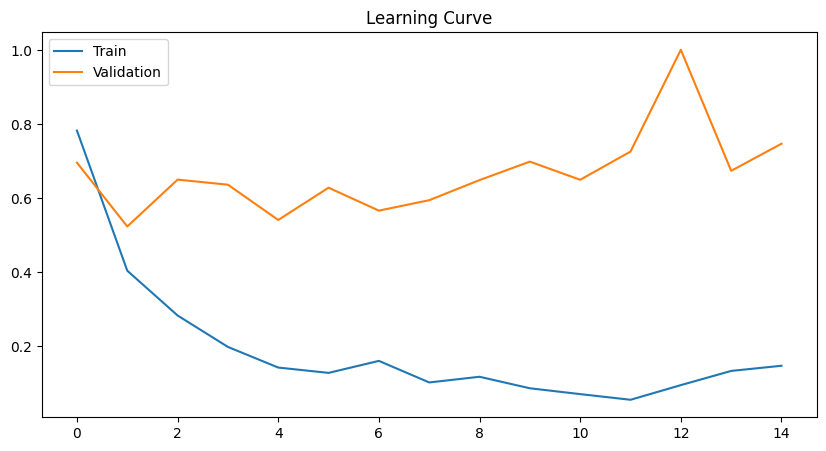

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.legend()

plt.title(
    "Learning Curve"
)

save_plot(
    "learning_curve",
    "training"
)

plt.show()

Accuracy Curve

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/training/accuracy_curve.png


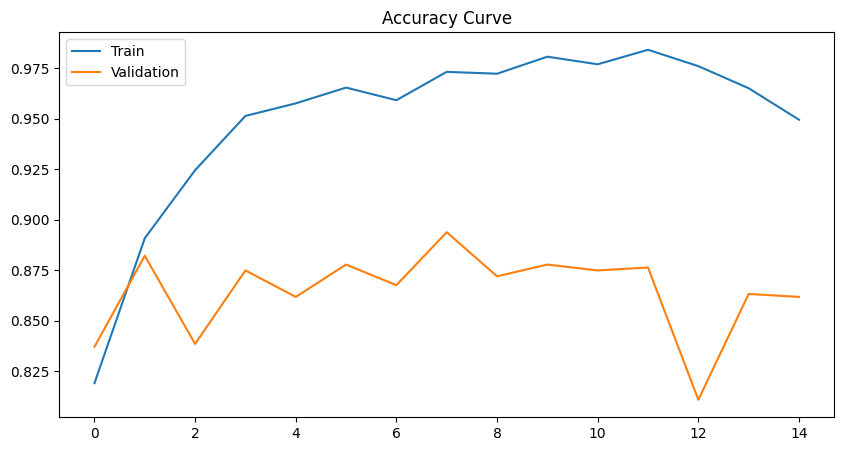

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accs,
    label="Train"
)

plt.plot(
    val_accs,
    label="Validation"
)

plt.legend()

plt.title(
    "Accuracy Curve"
)

save_plot(
    "accuracy_curve",
    "training"
)

plt.show()

Save Final Model

In [ ]:
torch.save(

    model.state_dict(),

    f"{PROJECT_DIR}/models/final_resnet50.pth"
)

print(
    "Final Model Saved"
)

Final Model Saved


SECTION F — Evaluation, Confusion Matrix & Research Reporting

Load Best Model

In [ ]:
model.load_state_dict(

    torch.load(
        f"{PROJECT_DIR}/models/best_resnet50.pth"
    )
)

model.eval()

print(
    "Best Model Loaded"
)

Best Model Loaded


Test Predictions

In [ ]:
all_preds = []

all_labels = []

all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs1 = model(images)

        outputs2 = model(
            torch.flip(
                images,
                dims=[3]
            )
        )

        outputs = (
            outputs1 +
            outputs2
        ) / 2

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

Overall Accuracy

In [ ]:
test_accuracy = accuracy_score(

    all_labels,

    all_preds
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Accuracy: 0.8879


In [ ]:
from sklearn.metrics import top_k_accuracy_score

top5_acc = top_k_accuracy_score(

    all_labels,

    np.array(all_probs),

    k=5
)

print(
    f"Top-5 Accuracy: {top5_acc:.4f}"
)

Top-5 Accuracy: 0.9665


Save Accuracy

In [ ]:
accuracy_df = pd.DataFrame({

    "Metric":[
        "Top-1 Accuracy",
        "Top-5 Accuracy"
    ],

    "Value":[
        test_accuracy,
        top5_acc
    ]
})

accuracy_df.to_csv(

    f"{PROJECT_DIR}/results/test_accuracy.csv",

    index=False
)

accuracy_df

,Metric,Value
0,Top-1 Accuracy,0.887918
1,Top-5 Accuracy,0.966521


Classification Report

In [ ]:
report = classification_report(

    all_labels,

    all_preds,

    target_names=dataset.classes,

    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.head()

,precision,recall,f1-score,support
Aalubhat,1.0,1.000,1.000000,7.0
Alfredo_Pasta,1.0,0.800,0.888889,5.0
Aloo_Paratha,1.0,1.000,1.000000,8.0
Aloo_sabji,1.0,0.875,0.933333,8.0
Alu_vadi,1.0,1.000,1.000000,5.0


Save Classification Report

In [ ]:
report_df.to_csv(

    f"{PROJECT_DIR}/reports/classification_report.csv"
)

print(
    "Classification Report Saved"
)

Classification Report Saved


Precision / Recall / F1 Summary

In [ ]:
summary_metrics = pd.DataFrame({

    "Metric":[

        "Precision",

        "Recall",

        "F1-Score"
    ],

    "Value":[

        report["weighted avg"]["precision"],

        report["weighted avg"]["recall"],

        report["weighted avg"]["f1-score"]
    ]
})

summary_metrics

,Metric,Value
0,Precision,0.914199
1,Recall,0.887918
2,F1-Score,0.887076


Save Summary Metrics

In [ ]:
summary_metrics.to_csv(

    f"{PROJECT_DIR}/reports/summary_metrics.csv",

    index=False
)

Confusion Matrix

In [ ]:
cm = confusion_matrix(

    all_labels,

    all_preds
)

cm.shape

(100, 100)

Save Confusion Matrix CSV

In [ ]:
cm_df = pd.DataFrame(cm)

cm_df.to_csv(

    f"{PROJECT_DIR}/results/confusion_matrix.csv",

    index=False
)

Most Confused Class Pairs

In [ ]:
cm_copy = cm.copy()

np.fill_diagonal(
    cm_copy,
    0
)

pairs = []

for i in range(len(cm_copy)):

    j = np.argmax(
        cm_copy[i]
    )

    pairs.append(

        (
            dataset.classes[i],

            dataset.classes[j],

            cm_copy[i,j]
        )
    )

pairs = sorted(

    pairs,

    key=lambda x:x[2],

    reverse=True
)

confused_pairs_df = pd.DataFrame(

    pairs,

    columns=[
        "True",
        "Predicted",
        "Count"
    ]
)

confused_pairs_df.head(20)

,True,Predicted,Count
0,Chicken_biryani,Veg_fried_noodles,3
1,Fried_rice,Sabudana_Usal,2
2,Khichadi,Masala_rice,2
3,Masala_rice,Veg_fried_noodles,2
4,Pav_bhaji,Misal_pav,2
5,Veg_Manchurian,Chicken_curry,2
6,Alfredo_Pasta,Veg_fried_noodles,1
7,Aloo_sabji,Chicken_fry,1
8,Appam,Brinjal_dry,1
9,Basundi,Rasgulla,1


Save Most Confused Pairs

In [ ]:
confused_pairs_df.to_csv(

    f"{PROJECT_DIR}/reports/confused_pairs.csv",

    index=False
)

print(
    "Confused Pairs Saved"
)

Confused Pairs Saved


Confusion Matrix Plot

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/evaluation/confusion_matrix.png


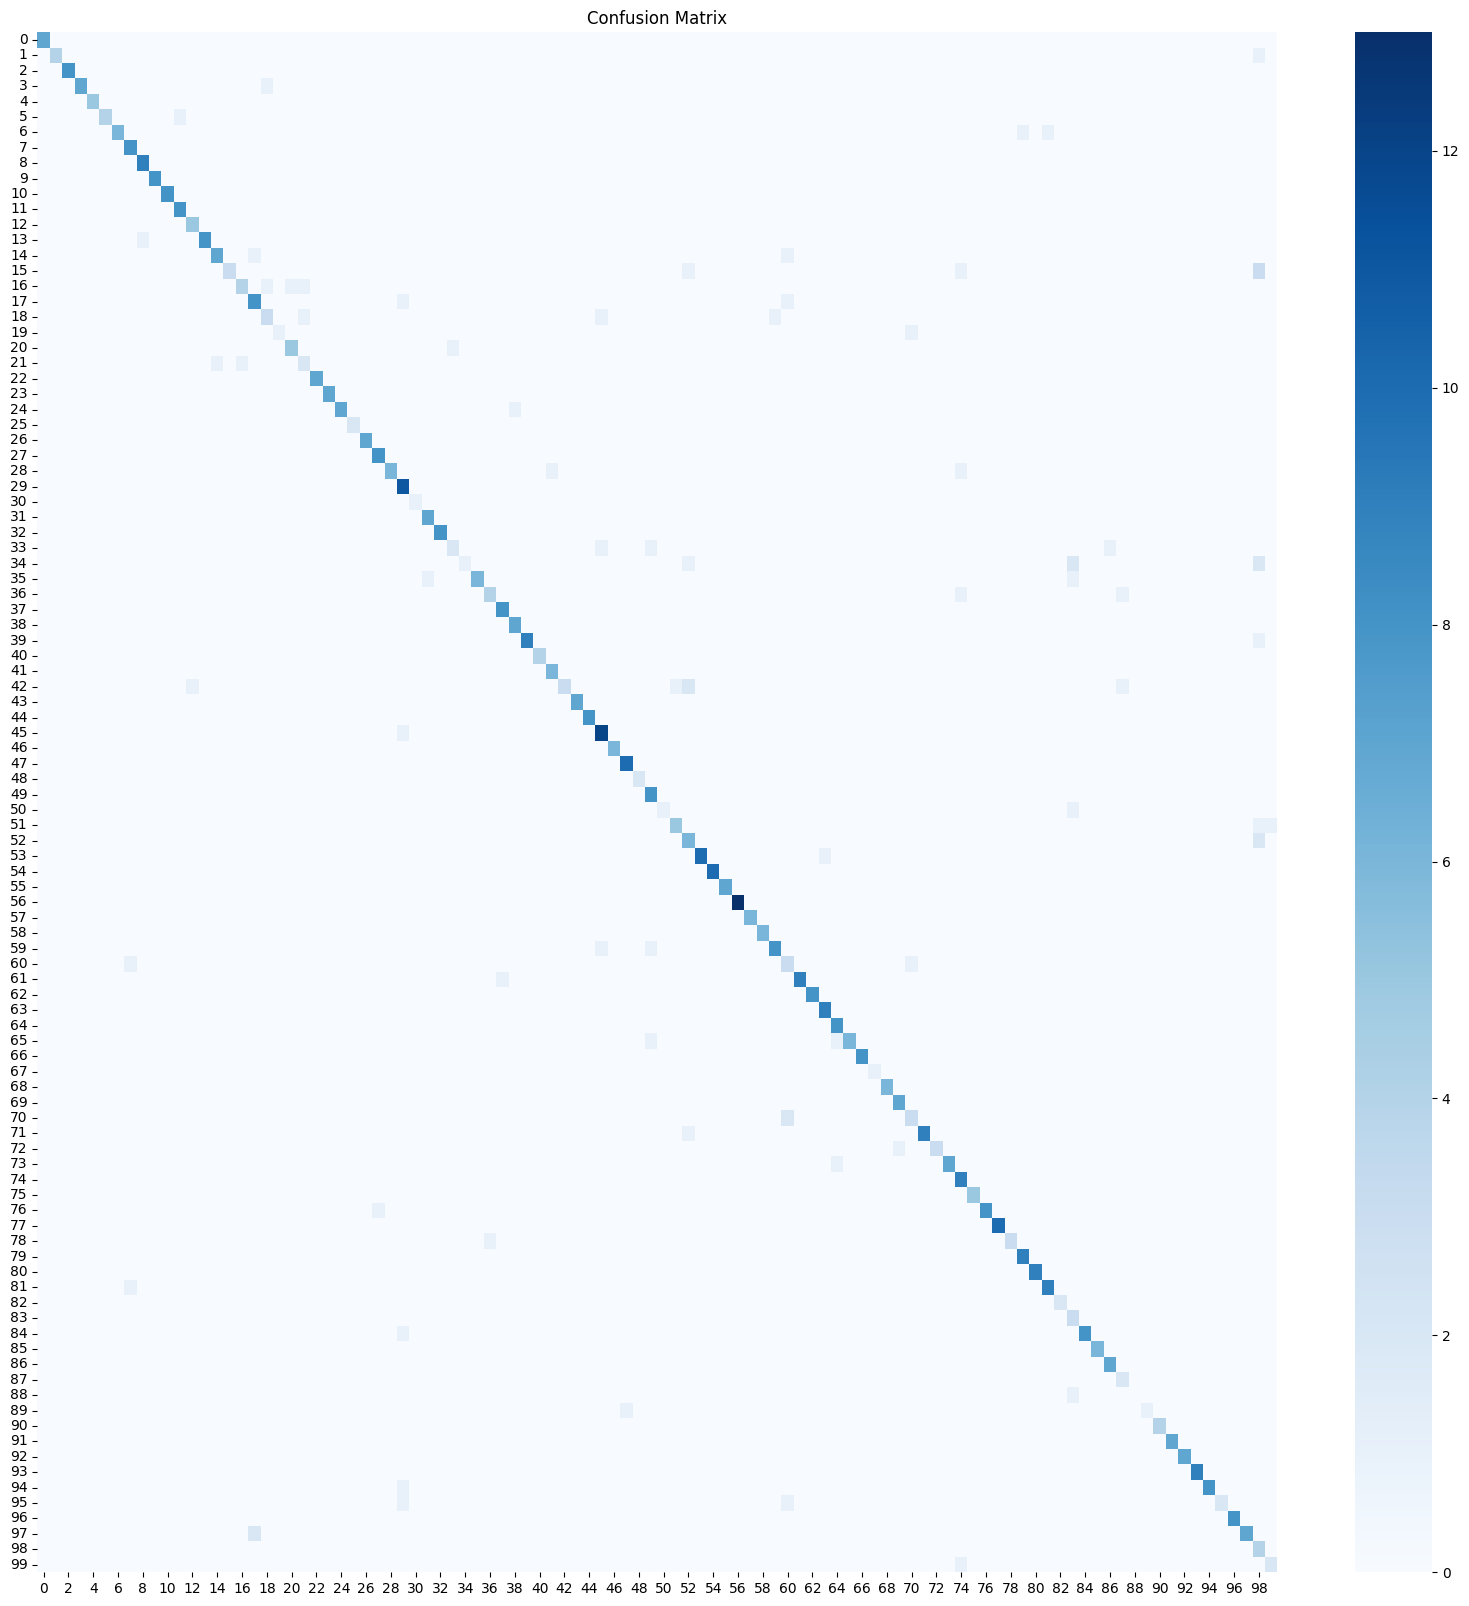

In [ ]:
plt.figure(

    figsize=(20,20)
)

sns.heatmap(

    cm,

    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

save_plot(
    "confusion_matrix",
    "evaluation"
)

plt.show()

Per-Class Accuracy

In [ ]:
class_accuracy = []

for class_id in range(
    len(dataset.classes)
):

    idxs = [

        i

        for i, label

        in enumerate(all_labels)

        if label == class_id
    ]

    correct = sum(

        all_preds[i]
        ==
        all_labels[i]

        for i in idxs
    )

    acc = correct / len(idxs)

    class_accuracy.append(acc)

Per-Class Accuracy Table

In [ ]:
per_class_df = pd.DataFrame({

    "Class":
        dataset.classes,

    "Accuracy":
        class_accuracy
})

per_class_df.head()

,Class,Accuracy
0,Aalubhat,1.000
1,Alfredo_Pasta,0.800
2,Aloo_Paratha,1.000
3,Aloo_sabji,0.875
4,Alu_vadi,1.000


Save Per-Class Accuracy

In [ ]:
per_class_df.to_csv(

    f"{PROJECT_DIR}/results/per_class_accuracy.csv",

    index=False
)

Top 20 Best Classes

In [ ]:
best_classes = per_class_df.sort_values(

    by="Accuracy",

    ascending=False
).head(20)

best_classes

,Class,Accuracy
0,Aalubhat,1.0
2,Aloo_Paratha,1.0
7,Bhakri_thecha,1.0
4,Alu_vadi,1.0
29,Dosa,1.0
30,Egg_bhurji,1.0
9,Bombay_Halwa,1.0
8,Bhindi_Sabji,1.0
10,Brinjal_Curry,1.0
11,Brinjal_dry,1.0


Plot Best Classes

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/evaluation/best_classes.png


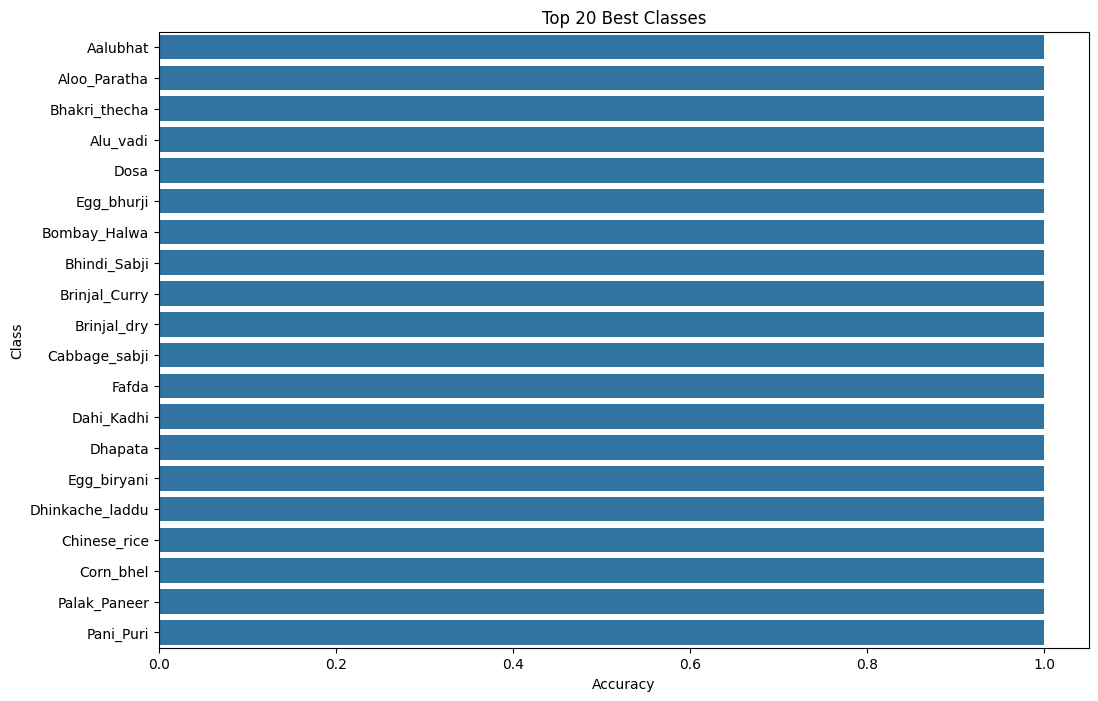

In [ ]:
plt.figure(

    figsize=(12,8)
)

sns.barplot(

    data=best_classes,

    x="Accuracy",

    y="Class"
)

plt.title(
    "Top 20 Best Classes"
)

save_plot(
    "best_classes",
    "evaluation"
)

plt.show()

Top 20 Worst Classes

In [ ]:
worst_classes = per_class_df.sort_values(

    by="Accuracy"

).head(20)

worst_classes

,Class,Accuracy
88,Spicy_vatana,0.000000
34,Fried_rice,0.166667
42,Khichadi,0.375000
15,Chicken_biryani,0.375000
33,Fish_fry,0.400000
50,Masala_oats,0.500000
18,Chicken_fry,0.500000
21,Chilli_chicken,0.500000
89,Strawberry_shrikhand,0.500000
95,Vadapav,0.500000


Plot Worst Classes

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/evaluation/worst_classes.png


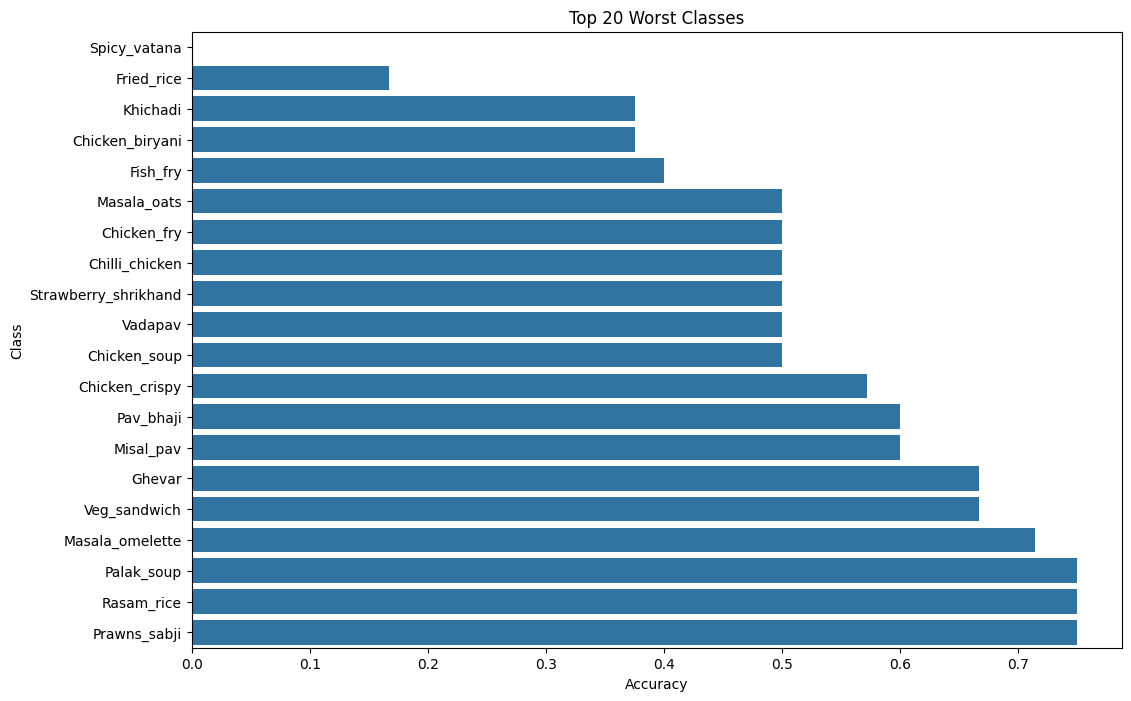

In [ ]:
plt.figure(

    figsize=(12,8)
)

sns.barplot(

    data=worst_classes,

    x="Accuracy",

    y="Class"
)

plt.title(
    "Top 20 Worst Classes"
)

save_plot(
    "worst_classes",
    "evaluation"
)

plt.show()

Accuracy Distribution

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/evaluation/accuracy_distribution.png


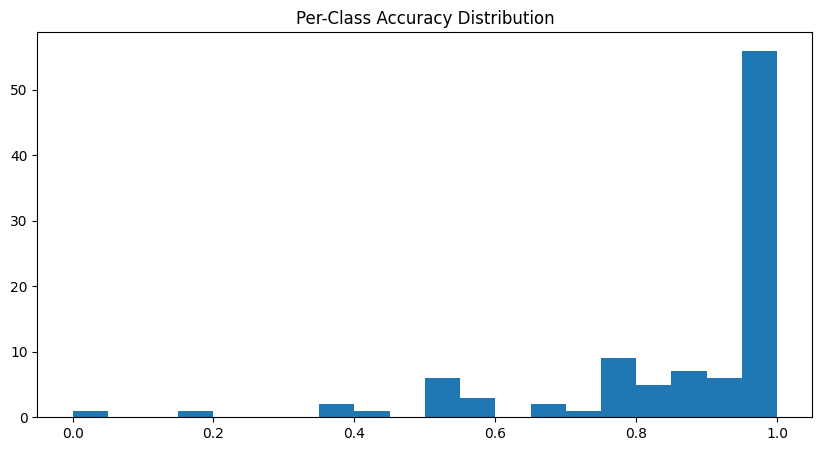

In [ ]:
plt.figure(

    figsize=(10,5)
)

plt.hist(

    class_accuracy,

    bins=20
)

plt.title(
    "Per-Class Accuracy Distribution"
)

save_plot(
    "accuracy_distribution",
    "evaluation"
)

plt.show()

Misclassified Samples

In [ ]:
misclassified = []

counter = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        for i in range(
            len(images)
        ):

            if preds[i] != labels[i]:

                misclassified.append(

                    (
                        images[i].cpu(),

                        labels[i].item(),

                        preds[i].item()
                    )
                )

                counter += 1

            if counter >= 20:
                break

        if counter >= 20:
            break

len(misclassified)

20

Visualize Misclassifications

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/evaluation/misclassified_examples.png


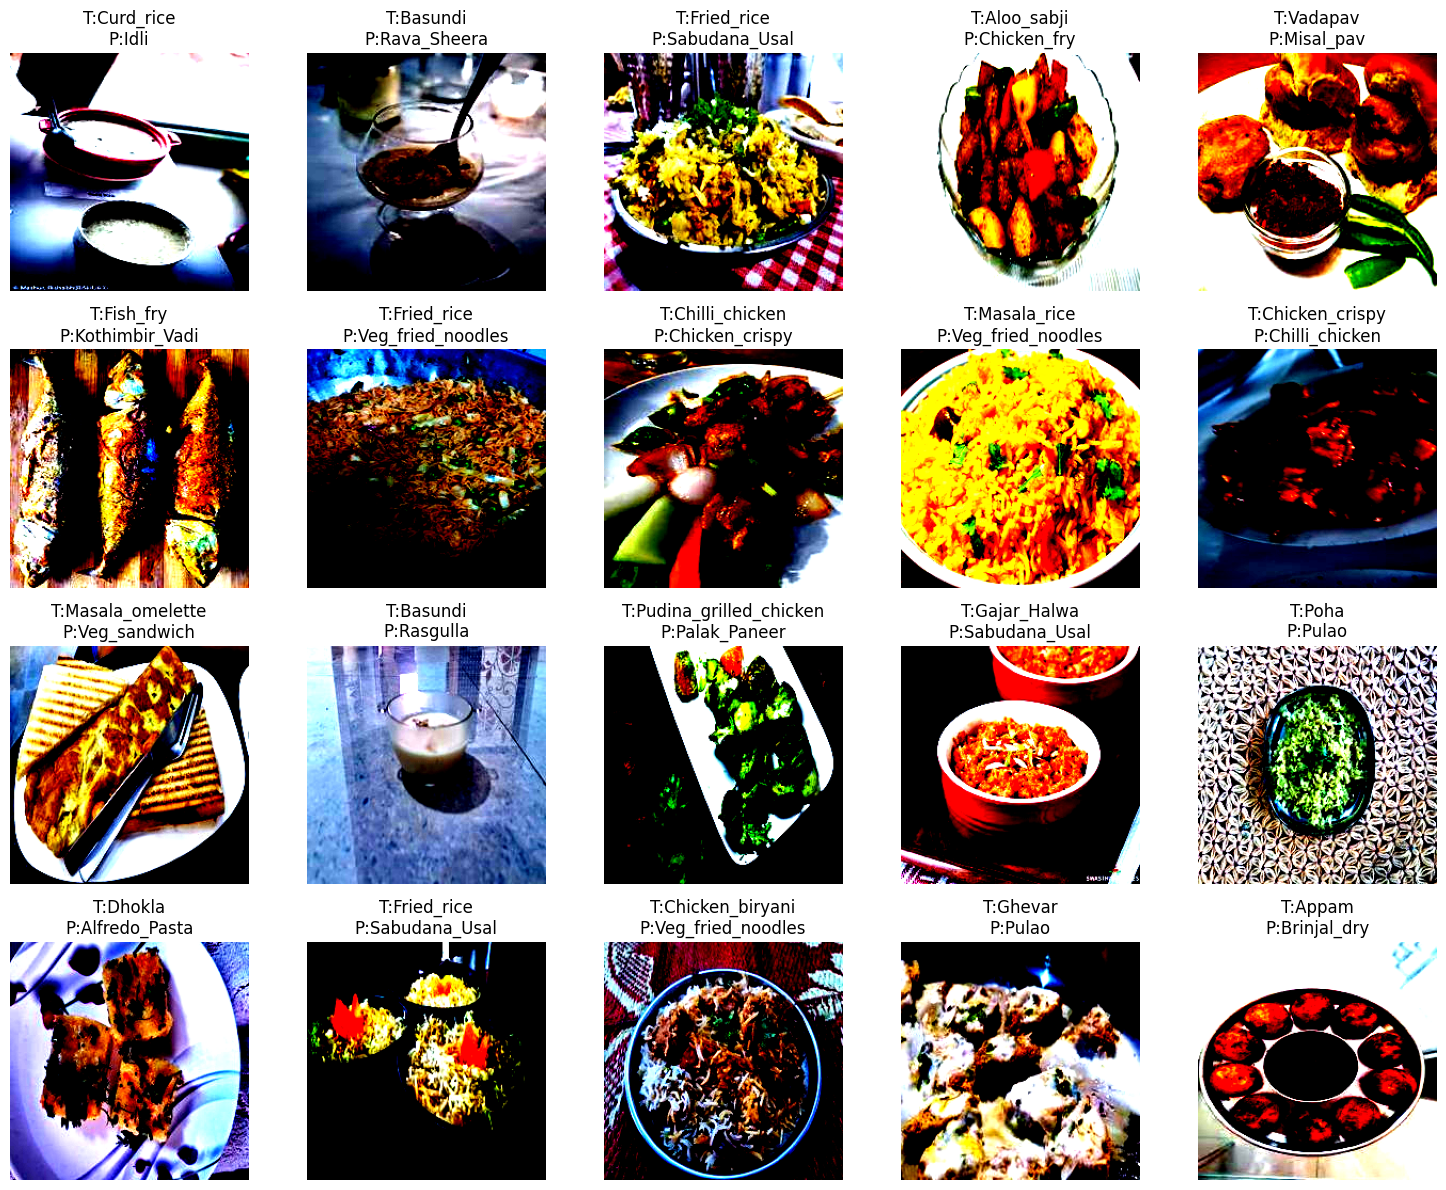

In [ ]:
fig, axes = plt.subplots(

    4,
    5,

    figsize=(15,12)
)

for ax, sample in zip(

    axes.flatten(),

    misclassified
):

    image, true_label, pred_label = sample

    image = image.permute(

        1,
        2,
        0
    )

    ax.imshow(image)

    ax.set_title(

        f"T:{dataset.classes[true_label]}\n"

        f"P:{dataset.classes[pred_label]}"
    )

    ax.axis("off")

plt.tight_layout()

save_plot(
    "misclassified_examples",
    "evaluation"
)

plt.show()

Dataset Summary for Paper

In [ ]:
paper_results = pd.DataFrame({

    "Metric":[

        "Top-1 Accuracy",

        "Top-5 Accuracy",

        "Precision",

        "Recall",

        "F1 Score"
    ],

    "Value":[

        test_accuracy,

        top5_acc,

        report["weighted avg"]["precision"],

        report["weighted avg"]["recall"],

        report["weighted avg"]["f1-score"]
    ]
})

paper_results

,Metric,Value
0,Top-1 Accuracy,0.887918
1,Top-5 Accuracy,0.966521
2,Precision,0.914199
3,Recall,0.887918
4,F1 Score,0.887076


Save Paper Results

In [ ]:
paper_results.to_csv(

    f"{PROJECT_DIR}/reports/paper_results.csv",

    index=False
)

Generate Final Experiment Summary

In [ ]:
summary = {

    "Classes":
        len(dataset.classes),

    "Images":
        len(dataset),

    "Train Samples":
        len(train_idx),

    "Validation Samples":
        len(val_idx),

    "Test Samples":
        len(test_idx),

    "Test Accuracy":
        test_accuracy,

    "Precision":
        report["weighted avg"]["precision"],

    "Recall":
        report["weighted avg"]["recall"],

    "F1":
        report["weighted avg"]["f1-score"]
}

summary_df = pd.DataFrame(
    [summary]
)

summary_df

,Classes,Images,Train Samples,Validation Samples,Test Samples,Test Accuracy,Precision,Recall,F1
0,100,4578,3204,687,687,0.887918,0.914199,0.887918,0.887076


Save Experiment Summary

In [ ]:
summary_df.to_csv(

    f"{PROJECT_DIR}/reports/experiment_summary.csv",

    index=False
)

print(
    "Experiment Summary Saved"
)

Experiment Summary Saved


SECTION G — Final Research Package & Reproducibility

Create Final Results Summary

In [ ]:
final_summary = {

    "Dataset": "Indian Food Dataset",

    "Total Images": len(dataset),

    "Total Classes": len(dataset.classes),

    "Train Samples": len(train_idx),

    "Validation Samples": len(val_idx),

    "Test Samples": len(test_idx),

    "Top-1 Accuracy": test_accuracy,

    "Top-5 Accuracy": top5_acc,

    "Precision": report["weighted avg"]["precision"],

    "Recall": report["weighted avg"]["recall"],

    "F1 Score": report["weighted avg"]["f1-score"]
}

final_summary_df = pd.DataFrame(
    [final_summary]
)

final_summary_df

,Dataset,Total Images,Total Classes,Train Samples,Validation Samples,Test Samples,Top-1 Accuracy,Top-5 Accuracy,Precision,Recall,F1 Score
0,Indian Food Dataset,4578,100,3204,687,687,0.887918,0.966521,0.914199,0.887918,0.887076


Save Final Summary

In [ ]:
final_summary_df.to_csv(

    f"{PROJECT_DIR}/reports/final_summary.csv",

    index=False
)

print("Final Summary Saved")

Final Summary Saved


Create Experiment Metadata

In [ ]:
metadata = {

    "Model":"ResNet50",

    "Pretrained":"ImageNet",

    "Epochs":EPOCHS,

    "Batch Size":32,

    "Optimizer":"AdamW",

    "Scheduler":"CosineAnnealingLR",

    "Image Size":"224x224",

    "Classes":len(dataset.classes),

    "Images":len(dataset)
}

metadata_df = pd.DataFrame(
    [metadata]
)

metadata_df

,Model,Pretrained,Epochs,Batch Size,Optimizer,Scheduler,Image Size,Classes,Images
0,ResNet50,ImageNet,35,32,AdamW,CosineAnnealingLR,224x224,100,4578


Save Metadata

In [ ]:
metadata_df.to_csv(

    f"{PROJECT_DIR}/reports/experiment_metadata.csv",

    index=False
)

Create Publication Dataset Table

In [ ]:
dataset_table = pd.DataFrame({

    "Metric":[

        "Total Images",

        "Total Classes",

        "Mean Images/Class",

        "Median Images/Class",

        "Imbalance Ratio"
    ],

    "Value":[

        stats["Total Images"],

        stats["Total Classes"],

        stats["Mean Images Per Class"],

        stats["Median Images Per Class"],

        stats["Imbalance Ratio"]
    ]
})

dataset_table

,Metric,Value
0,Total Images,4578.00
1,Total Classes,100.00
2,Mean Images/Class,45.78
3,Median Images/Class,50.00
4,Imbalance Ratio,11.86


Save Publication Dataset Table

In [ ]:
dataset_table.to_csv(

    f"{PROJECT_DIR}/reports/publication_dataset_table.csv",

    index=False
)

Create Publication Results Table

In [ ]:
results_table = pd.DataFrame({

    "Metric":[

        "Top1 Accuracy",

        "Top5 Accuracy",

        "Precision",

        "Recall",

        "F1 Score"
    ],

    "Value":[

        test_accuracy,

        top5_acc,

        report["weighted avg"]["precision"],

        report["weighted avg"]["recall"],

        report["weighted avg"]["f1-score"]
    ]
})

results_table

,Metric,Value
0,Top1 Accuracy,0.887918
1,Top5 Accuracy,0.966521
2,Precision,0.914199
3,Recall,0.887918
4,F1 Score,0.887076


Save Publication Results Table

In [ ]:
results_table.to_csv(

    f"{PROJECT_DIR}/reports/publication_results_table.csv",

    index=False
)

Generate README Text

In [ ]:
readme_text = f"""
Indian Food Recognition Research Project

Dataset:
- Images: {len(dataset)}
- Classes: {len(dataset.classes)}

Model:
- ResNet50 (ImageNet Pretrained)

Results:
- Top1 Accuracy: {test_accuracy:.4f}
- Top5 Accuracy: {top5_acc:.4f}
- Precision: {report['weighted avg']['precision']:.4f}
- Recall: {report['weighted avg']['recall']:.4f}
- F1 Score: {report['weighted avg']['f1-score']:.4f}

Generated Automatically
"""

print(readme_text)


Indian Food Recognition Research Project

Dataset:
- Images: 4578
- Classes: 100

Model:
- ResNet50 (ImageNet Pretrained)

Results:
- Top1 Accuracy: 0.8879
- Top5 Accuracy: 0.9665
- Precision: 0.9142
- Recall: 0.8879
- F1 Score: 0.8871

Generated Automatically



Save README

In [ ]:
with open(

    f"{PROJECT_DIR}/README.txt",

    "w"

) as f:

    f.write(readme_text)

print("README Saved")

README Saved
